In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

----Data Preparation part 1

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
for col in df.columns[df.dtypes == 'str']:
    df[col] = df[col].str.lower().str.replace({' ':'_', '-':'_'})

In [5]:
del df['customerid']

In [6]:
from utils import *

In [7]:
df_info(df)

,type,unique_values
gender,str,2
seniorcitizen,int64,2
partner,str,2
dependents,str,2
tenure,int64,73
phoneservice,str,2
multiplelines,str,3
internetservice,str,3
onlinesecurity,str,3
onlinebackup,str,3


In [8]:
df = df.drop(list(df.totalcharges[df.totalcharges == '_'].index))
df = df.reset_index(drop= True)

In [9]:
df.shape

(7032, 20)

In [10]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'])

In [11]:
df['churn'] = df['churn'].map({'yes': 1, 'no': 0})

----Split the Data Set into train, validation and test Set

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
df_full_train, df_test = train_test_split(df, test_size= 0.2, random_state= 1)
df_train, df_val = train_test_split(df_full_train, test_size= 0.25, random_state= 1)

In [14]:
df_train = df_train.reset_index(drop= True)
df_val = df_val.reset_index(drop= True)
df_test = df_test.reset_index(drop= True)

In [15]:
y_train = df_train['churn'].values
y_val = df_val['churn'].values
y_test = df_test['churn'].values

In [16]:
df_full_train = df_full_train.reset_index(drop= True)

----EDA

In [17]:
numerical_var = ['tenure', 'monthlycharges', 'totalcharges']
categorical_var = [cat for cat in df.columns if cat not in numerical_var][:-1]

------Feature Importance

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
churn_rate = df['churn'].mean()

In [20]:
churn_max_rate_list = []
for cat in categorical_var:
    churn_max = df.groupby(cat)['churn'].mean().max()
    churn_max_rate_list.append(churn_max)

categorical_var_sorted = [s[1] for s in sorted(list(zip(churn_max_rate_list, categorical_var)))]

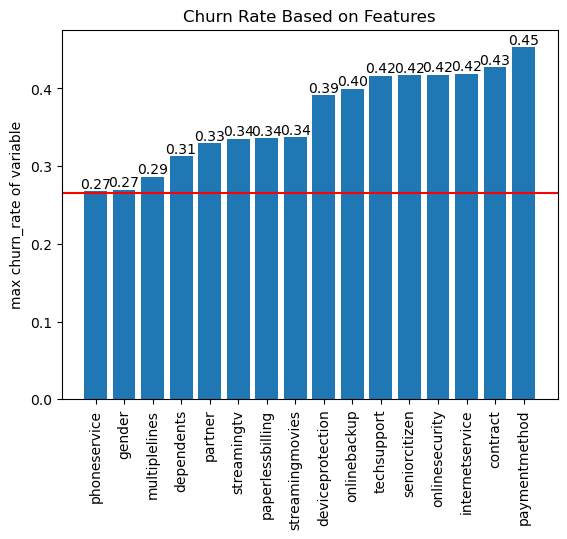

In [21]:
bars = plt.bar(categorical_var_sorted, list(sorted(churn_max_rate_list)))
plt.axhline(y = churn_rate, color= 'red')
plt.xticks(rotation = 90)
plt.bar_label(bars, fmt= '%.2f')
plt.ylabel('max churn_rate of variable')
plt.title('Churn Rate Based on Features') 
plt.show()

In [22]:
more_important_feature = categorical_var_sorted[-5:][::-1]

In [23]:
more_important_feature

['paymentmethod',
 'contract',
 'internetservice',
 'onlinesecurity',
 'seniorcitizen']

------ --Mutual Information & Entropy

In [24]:
from sklearn.metrics import mutual_info_score
from utils import *

In [25]:
mi_list = []
for cat in categorical_var_sorted:
    mi = mutual_info_score(df['churn'], df[cat])
    mi_list.append(mi)
mutual_info_df = pd.DataFrame(zip(categorical_var_sorted, mi_list), columns=['category', 'mutual_info']).sort_values(by= 'mutual_info', ascending= False)

In [26]:
entropia_list = []
for cat in categorical_var_sorted:
    entropia = conditional_entropy(df, 'churn', cat)
    entropia_list.append(entropia)

churn_entropy = entropy(df, 'churn')

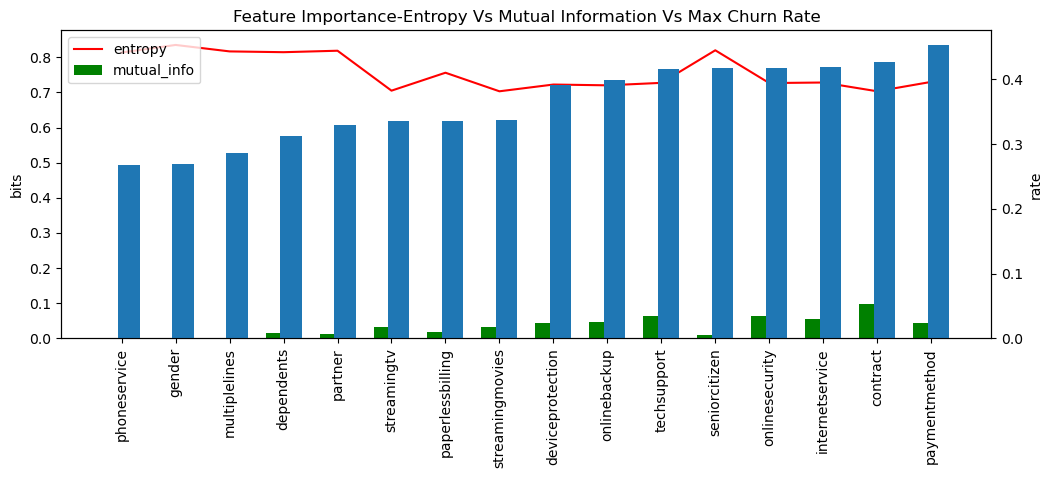

In [27]:
bar_ = np.arange(len(categorical_var_sorted))
width = 0.4
fig, ax1 = plt.subplots(figsize= (12, 4))
ax1.bar(bar_ - width / 3, mi_list, width= width, label= 'mutual_info', color= 'green')
ax1.set_ylabel('bits')
ax2 = ax1.twinx()
ax2.bar(bar_ + width / 3, list(sorted(churn_max_rate_list)), width= width, label= 'max_churn_rate')
ax2.set_ylabel('rate')
ax1.plot(categorical_var_sorted, entropia_list, color= 'red', label= 'entropy')
ax1.set_xticks(bar_, categorical_var_sorted, rotation= 90)
ax1.legend(loc= 'upper left')
plt.title('Feature Importance-Entropy Vs Mutual Information Vs Max Churn Rate')
plt.show()

------ --Churn Rate - Tenure

In [28]:
tenure_list = [(0, 2), (3, 12), (13, 24), (25, 48), (49, 240)]
churn_rate_on_tenure = []
for i in tenure_list:
    churn_on_tenure = df_full_train[(df_full_train.tenure > i[0]) & (df_full_train.tenure < i[1])].churn.mean()
    churn_rate_on_tenure.append(churn_on_tenure)

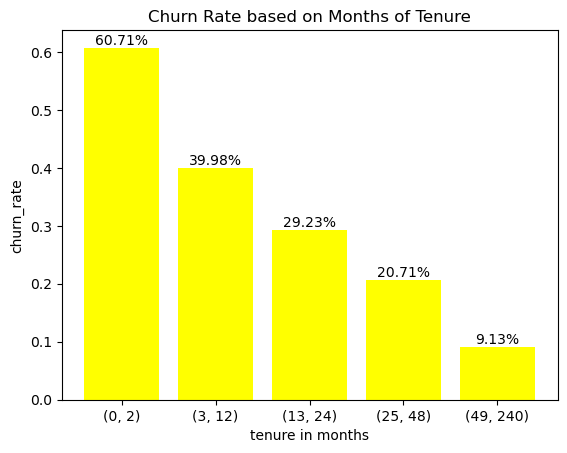

In [29]:
churn_bars = plt.bar([str(i) for i in tenure_list], churn_rate_on_tenure, color= 'yellow')
plt.xlabel('tenure in months')
plt.ylabel('churn_rate')
plt.bar_label(churn_bars, labels= [f'{v * 100:.2f}%' for v in churn_rate_on_tenure])
plt.title('Churn Rate based on Months of Tenure')
plt.show()

----Dummies OneHotEncoding

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [31]:
ct = ColumnTransformer(
    transformers=[('scaler', StandardScaler(), numerical_var),
                  ('ohe', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False), mutual_info_df.category[:5])],
    verbose_feature_names_out= False
    )

In [32]:
X_train = ct.fit_transform(df_train)
X_val = ct.transform(df_val)

In [33]:
df_X = pd.DataFrame(X_train, columns= ct.get_feature_names_out())

----Logistic Regression - Train the Model

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
model = LogisticRegression()

In [36]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
model.intercept_[0]

np.float64(-2.0751225903470965)

In [38]:
model.coef_[0]

array([-1.28438869,  0.45795295,  0.59403286,  0.77843964,  0.01490499,
       -0.79309347,  0.2912825 , -0.06130482, -0.22972651,  0.32248666,
       -0.06130482, -0.26093067, -0.11447695,  0.17603294, -0.06130482,
        0.13570823, -0.06130482, -0.07415224])

In [39]:
model.predict_proba(X_train)[:, 1]

array([0.1213815 , 0.05034943, 0.57878111, ..., 0.04922575, 0.52110527,
       0.05531375], shape=(4218,))

----Accuracy - Evaluate the Model

In [40]:
churn_pred = model.predict(X_val)

In [41]:
accuracy = (churn_pred == y_val).mean()

In [44]:
print(f'accuracy: {100 * accuracy:.2f}%')

accuracy: 79.00%
